<a href="https://colab.research.google.com/github/Elsaterziu/ml-project/blob/feature%2Fpreprocessing-logistic-regression/notebooks/patient_no_show_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Patient No-Show Prediction

This notebook applies machine learning techniques to predict whether a patient is likely to miss a medical appointment.  
The project is connected to the Clinic Management System from Lab 2, where this model can later be integrated into the appointments module.

In [86]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Original Dataset

The original dataset is loaded from the CSV file. This dataset contains medical appointment records and the target column `No-show`.

In [55]:
`from google.colab import files
uploaded = files.upload()

Saving appointments.csv to appointments (1).csv


In [56]:
df = pd.read_csv("appointments.csv")
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


## Initial Dataset Inspection

In this section, we check the dataset size, column types, missing values, duplicate rows, and target distribution.

In [57]:
print("Dataset shape:", df.shape)

Dataset shape: (110527, 14)


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [59]:
df.isnull().sum()

,0
PatientId,0
AppointmentID,0
Gender,0
ScheduledDay,0
AppointmentDay,0
Age,0
Neighbourhood,0
Scholarship,0
Hipertension,0
Diabetes,0


In [60]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [61]:
df["No-show"].value_counts()

,count
No-show,
No,88208
Yes,22319


In [62]:
df["No-show"].value_counts(normalize=True) * 100

,proportion
No-show,
No,79.806744
Yes,20.193256


## Data Cleaning and Feature Engineering

The dataset is cleaned by removing invalid values, converting date columns, creating new date-based features, renaming columns, and converting the target variable into numeric format.

In [63]:
# Remove invalid age values
df = df[df["Age"] >= 0].copy()

# Convert date columns safely
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"], errors="coerce", utc=True)
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"], errors="coerce", utc=True)

# Check if any date values failed to convert
print(df[["ScheduledDay", "AppointmentDay"]].isnull().sum())

# Remove rows where date conversion failed
df = df.dropna(subset=["ScheduledDay", "AppointmentDay"]).copy()

# Create new date-based features
df["WaitingDays"] = (
    df["AppointmentDay"].dt.normalize() - df["ScheduledDay"].dt.normalize()
).dt.days

df["AppointmentWeekDay"] = df["AppointmentDay"].dt.dayofweek
df["ScheduledHour"] = df["ScheduledDay"].dt.hour

# Remove invalid waiting days
df = df[df["WaitingDays"] >= 0].copy()

# Rename misspelled columns
df = df.rename(columns={
    "Hipertension": "Hypertension",
    "Handcap": "Handicap"
})

# Convert target variable to numeric
# 0 = Patient showed up
# 1 = Patient did not show up
df["NoShow"] = df["No-show"].map({"No": 0, "Yes": 1})

# Drop columns not used for training
df_cleaned = df.drop(columns=[
    "PatientId",
    "AppointmentID",
    "ScheduledDay",
    "AppointmentDay",
    "No-show"
])

df_cleaned.head()

ScheduledDay      0
AppointmentDay    0
dtype: int64


,Gender,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,WaitingDays,AppointmentWeekDay,ScheduledHour,NoShow
0,F,62,JARDIM DA PENHA,0,1,0,0,0,0,0,4,18,0
1,M,56,JARDIM DA PENHA,0,0,0,0,0,0,0,4,16,0
2,F,62,MATA DA PRAIA,0,0,0,0,0,0,0,4,16,0
3,F,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,4,17,0
4,F,56,JARDIM DA PENHA,0,1,1,0,0,0,0,4,16,0


## Check Cleaned Dataset

After cleaning, the final dataset is checked again to make sure it has no missing values and contains the correct columns.


In [64]:
print("Cleaned dataset shape:", df_cleaned.shape)

Cleaned dataset shape: (110521, 13)


In [65]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110521 entries, 0 to 110526
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   Gender              110521 non-null  object
 1   Age                 110521 non-null  int64 
 2   Neighbourhood       110521 non-null  object
 3   Scholarship         110521 non-null  int64 
 4   Hypertension        110521 non-null  int64 
 5   Diabetes            110521 non-null  int64 
 6   Alcoholism          110521 non-null  int64 
 7   Handicap            110521 non-null  int64 
 8   SMS_received        110521 non-null  int64 
 9   WaitingDays         110521 non-null  int64 
 10  AppointmentWeekDay  110521 non-null  int32 
 11  ScheduledHour       110521 non-null  int32 
 12  NoShow              110521 non-null  int64 
dtypes: int32(2), int64(9), object(2)
memory usage: 11.0+ MB


In [66]:
df_cleaned.isnull().sum()

,0
Gender,0
Age,0
Neighbourhood,0
Scholarship,0
Hypertension,0
Diabetes,0
Alcoholism,0
Handicap,0
SMS_received,0
WaitingDays,0


In [67]:
df_cleaned["NoShow"].value_counts()

,count
NoShow,
0,88207
1,22314


In [68]:
df_cleaned["NoShow"].value_counts(normalize=True) * 100

,proportion
NoShow,
0,79.810172
1,20.189828


## Save Cleaned Dataset

The cleaned dataset is saved as a new CSV file so it can be reused for model training.

In [69]:
df_cleaned.to_csv("appointments_cleaned.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [70]:
files.download("appointments_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Load Cleaned Dataset for Model Training

The cleaned dataset is loaded again and used for machine learning model training.

In [71]:
# If appointments_cleaned.csv is already in the Colab session, this will work directly.
df_model = pd.read_csv("appointments_cleaned.csv")
df_model.head()

,Gender,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,WaitingDays,AppointmentWeekDay,ScheduledHour,NoShow
0,F,62,JARDIM DA PENHA,0,1,0,0,0,0,0,4,18,0
1,M,56,JARDIM DA PENHA,0,0,0,0,0,0,0,4,16,0
2,F,62,MATA DA PRAIA,0,0,0,0,0,0,0,4,16,0
3,F,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,4,17,0
4,F,56,JARDIM DA PENHA,0,1,1,0,0,0,0,4,16,0


In [72]:
print("Model dataset shape:", df_model.shape)
df_model.info()

Model dataset shape: (110521, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110521 entries, 0 to 110520
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   Gender              110521 non-null  object
 1   Age                 110521 non-null  int64 
 2   Neighbourhood       110521 non-null  object
 3   Scholarship         110521 non-null  int64 
 4   Hypertension        110521 non-null  int64 
 5   Diabetes            110521 non-null  int64 
 6   Alcoholism          110521 non-null  int64 
 7   Handicap            110521 non-null  int64 
 8   SMS_received        110521 non-null  int64 
 9   WaitingDays         110521 non-null  int64 
 10  AppointmentWeekDay  110521 non-null  int64 
 11  ScheduledHour       110521 non-null  int64 
 12  NoShow              110521 non-null  int64 
dtypes: int64(11), object(2)
memory usage: 11.0+ MB


## Define Features and Target

The target variable is `NoShow`.  
The features are all remaining columns except the target.

In [73]:
X = df_model.drop("NoShow", axis=1)
y = df_model["NoShow"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (110521, 12)
y shape: (110521,)


In [74]:
X.head()

,Gender,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,WaitingDays,AppointmentWeekDay,ScheduledHour
0,F,62,JARDIM DA PENHA,0,1,0,0,0,0,0,4,18
1,M,56,JARDIM DA PENHA,0,0,0,0,0,0,0,4,16
2,F,62,MATA DA PRAIA,0,0,0,0,0,0,0,4,16
3,F,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,4,17
4,F,56,JARDIM DA PENHA,0,1,1,0,0,0,0,4,16


In [75]:
y.value_counts()

,count
NoShow,
0,88207
1,22314


## Train-Test Split

The dataset is divided into training and testing sets.  
80% of the data is used for training and 20% is used for testing.

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)
print("Testing target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set: (88416, 12)
Testing set: (22105, 12)
Training target distribution:
NoShow
0    79.810215
1    20.189785
Name: proportion, dtype: float64
Testing target distribution:
NoShow
0    79.809998
1    20.190002
Name: proportion, dtype: float64


## Preprocessing Pipeline

The numeric features are scaled using StandardScaler.  
The categorical features are transformed using OneHotEncoder.

In [77]:
numeric_features = [
    "Age",
    "Scholarship",
    "Hypertension",
    "Diabetes",
    "Alcoholism",
    "Handicap",
    "SMS_received",
    "WaitingDays",
    "AppointmentWeekDay",
    "ScheduledHour"
]

categorical_features = [
    "Gender",
    "Neighbourhood"
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Age', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'WaitingDays', 'AppointmentWeekDay', 'ScheduledHour']
Categorical features: ['Gender', 'Neighbourhood']


In [78]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## Logistic Regression Model

Logistic Regression is used as the first baseline classification model.  


In [79]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Logistic Regression Evaluation

The model is evaluated using accuracy, precision, recall, F1-score, classification report, and confusion matrix.

In [80]:
y_pred_logistic = logistic_model.predict(X_test)

logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_logistic),
    "Precision": precision_score(y_test, y_pred_logistic, zero_division=0),
    "Recall": recall_score(y_test, y_pred_logistic, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_logistic, zero_division=0)
}

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.7955666138882606,
 'Precision': 0.3627450980392157,
 'Recall': 0.016580775263275824,
 'F1-score': 0.03171202056995929}

In [81]:
print(classification_report(y_test, y_pred_logistic, zero_division=0))

              precision    recall  f1-score   support

           0       0.80      0.99      0.89     17642
           1       0.36      0.02      0.03      4463

    accuracy                           0.80     22105
   macro avg       0.58      0.50      0.46     22105
weighted avg       0.71      0.80      0.71     22105



## Confusion Matrix

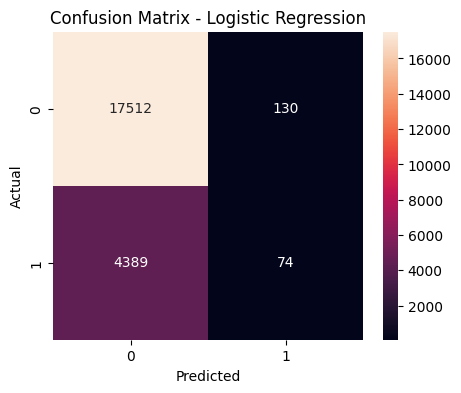

In [82]:
cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Save Logistic Regression Results

The Logistic Regression results are saved in a table so they can later be compared with other models.

In [83]:
results_df = pd.DataFrame([logistic_results])
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.795567,0.362745,0.016581,0.031712


In [84]:
results_df.to_csv("logistic_regression_results.csv", index=False)
print("Logistic Regression results saved successfully.")

Logistic Regression results saved successfully.


In [85]:
files.download("logistic_regression_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>